In [1]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
import json, os
import sys
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils
import matplotlib.pyplot as plt

In [2]:
%autoreload 2

In [3]:
#determine genotypes
paths = [r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish1",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish2",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish3",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish4",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish5",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish6",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish7",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish8",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish9",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish10",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish11",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish12",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish13",
r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\fish14"]

genotypes = {'Casper': [],
             'frmd7KO': []}
for path in paths:
    for file in os.scandir(path + '//eye//'):
        if 'metadata' in file.name:
            with open(path + '//eye//' + file.name, 'r', encoding='utf-8') as file:
                data = json.load(file)
    geno = data['general']['animal']['genotype']
    genotypes[geno].append(path)


__Get all saccade dataframes__

In [4]:
all_dfs = []
for geno in genotypes.keys():
    for fish in genotypes[geno]:
        saccade_df = pd.read_csv( fish + '//eye//eye_saccade_df.csv', index_col=0)#or proofread_eye_saccade_df
        saccade_df.loc[:, "fish_id"] = fish
        saccade_df.loc[:, "Genotype"] = geno
        all_dfs.append(saccade_df)
all_dfs = pd.concat(all_dfs).reset_index(drop = True)

all_dfs

,cont_tuples_eyeindex,cont_tuples_realtime_s,e0_change,e1_change,eye_stimuli,eye_realstimuli,eye_fromstart_s,e_conv_change,e_conj_change,fish_id,Genotype
0,"(np.int64(87), np.int64(139))","(np.float64(-2.8045), np.float64(-2.226046))",-1.264237,-1.626258,NaN,NaN,NaN,-0.362021,-2.890495,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,Casper
1,"(np.int64(1522), np.int64(1630))","(np.float64(13.130886), np.float64(14.330677))",10.102415,-6.135414,right,right,13.130886,-16.237828,3.967001,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,Casper
2,"(np.int64(1727), np.int64(1782))","(np.float64(15.406799), np.float64(16.018165))",-1.254555,-1.563991,right,right,15.406799,-0.309436,-2.818546,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,Casper
3,"(np.int64(1835), np.int64(1915))","(np.float64(16.606591), np.float64(17.495214))",8.844805,-1.459430,right,right,16.606591,-10.304235,7.385374,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,Casper
4,"(np.int64(2416), np.int64(2493))","(np.float64(23.058338), np.float64(23.913052))",-2.095381,-8.986277,right,right,23.058338,-6.890896,-11.081659,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,Casper
...,...,...,...,...,...,...,...,...,...,...,...
1917,"(np.int64(131689), np.int64(131768))","(np.float64(1459.780798), np.float64(1460.6554...",5.685289,7.620841,pause,stationary,258.498729,1.935552,13.306130,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,frmd7KO
1918,"(np.int64(132414), np.int64(132497))","(np.float64(1467.829275), np.float64(1468.7518...",-5.425105,-11.530452,pause,stationary,266.547206,-6.105347,-16.955557,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,frmd7KO
1919,"(np.int64(132743), np.int64(132816))","(np.float64(1471.484503), np.float64(1472.2933...",1.945051,5.908459,pause,stationary,270.202434,3.963408,7.853510,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,frmd7KO
1920,"(np.int64(133289), np.int64(133373))","(np.float64(1477.546289), np.float64(1478.4787...",10.449160,4.143174,pause,stationary,276.264220,-6.305986,14.592334,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,frmd7KO


In [5]:
all_dfs_byfish = all_dfs.drop(['cont_tuples_realtime_s', 'cont_tuples_eyeindex', 'eye_stimuli'], axis = 1).groupby(['eye_realstimuli', 'fish_id', 'Genotype']).mean().reset_index()

In [6]:
stimorder = ['stationary', 'left', 'right', 'dot_l', 'dot_r']

__EXAMPLE CODE: PLOT THE MEAN SACCADE ANGLE OF ALL FISH__

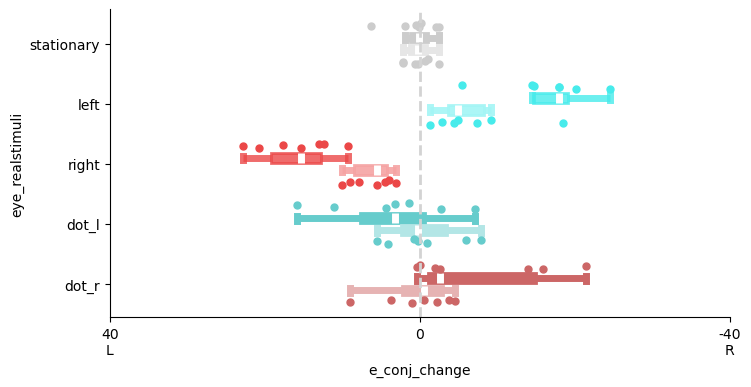

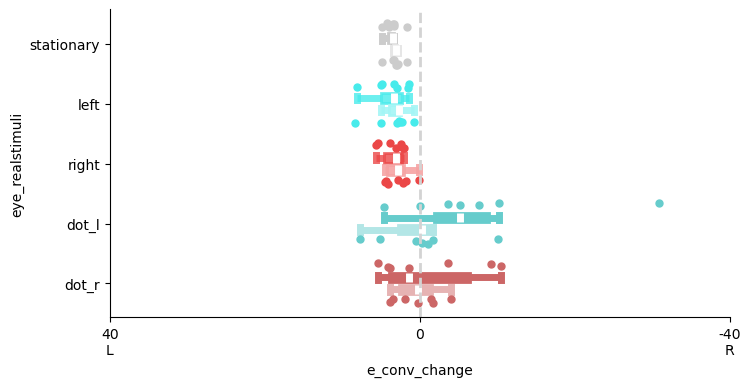

In [7]:
def plot_fish_saccade(all_df, stimorder, params, genotype):
    """Plot mean saccade for individual fish
    """
    fig, ax = plt.subplots(1, 1, figsize = (8, 4))
    bars = sns.boxplot(all_df, y = 'eye_realstimuli', x = params,  hue = 'Genotype', dodge = True, ax = ax, order= stimorder, hue_order = genotype, orient = 'h', linewidth=5, linecolor='white', zorder =0, width = 0.4, gap = 0.2, legend = False)

    #asign colors to the bar: less important
    count = all_df.groupby(['eye_realstimuli', 'Genotype']).count()
    count = list(count.reindex(stimorder, level='eye_realstimuli').iloc[:, 0])
    v = 0
    for i in range(len(count)):
        if count[i] > 0:  #box exist
            stim = stimorder[v % len(stimorder)]
            color = list(utils.stim_colors[stim])
            color = np.array(color)
            if i // (len(stimorder) ) != 0:
                color = 0.5 + 0.5 * np.array(color)
            bar = bars.patches[v]
            bar.set_edgecolor(color)
            bar.set_facecolor(color)
            bar.set_linewidth(2)
            for k in range(v * 6, (v + 1) * 6):
                if k != 4 + v * 6:
                    ax.lines[k].set_color(color)
            v += 1

    #plot scatter plot
    group_coord = [(-0.35, -0.25), (0.25, 0.35)]#[(-0.3, -0.28), (-0.12, -0.1), (0.1, 0.12), (0.28, 0.3)]#
    for i in range(0, len(stimorder)):
        for group_i, group in enumerate(genotype):
            x = stimorder[i]
            datatoplot = all_df[all_df.Genotype == group]
            y = list(datatoplot[datatoplot['eye_realstimuli'] == stimorder[i]][params])
            color = utils.stim_colors[x]
            ax.scatter(y = np.add([i] * len(y), np.random.uniform(group_coord[group_i][0], group_coord[group_i][1], len(y))), x=y,
                            color = color, alpha =1, s = 100, zorder = 1, marker = '.')

    #make axis prettier
    ax.axvline(0, linewidth = 2, color = 'lightgrey', linestyle = '--')
    ax.set_xlim([-40, 40])
    ax.spines[['top', 'right']].set_visible(False)

    ax.set_xlabel(params)

    ax.set_xticks([-40, 0, 40])
    ax.set_xticklabels(['40\nL', '0', '-40\nR'])

    plt.show()
    plt.close()
    return fig
fig = plot_fish_saccade(all_dfs_byfish, stimorder, 'e_conj_change', genotypes.keys())
plt.show()
plt.close()
fig.savefig(r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\all_behavior\individual_conj_byfish.svg")
fig = plot_fish_saccade(all_dfs_byfish, stimorder, 'e_conv_change', genotypes.keys())
plt.show()
plt.close()
fig.savefig(r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\all_behavior\individual_conv_byfish.svg")

__TASK 1: IS THERE A DIFFERENCE IN THE FREQUENCY OF SACCADE?__

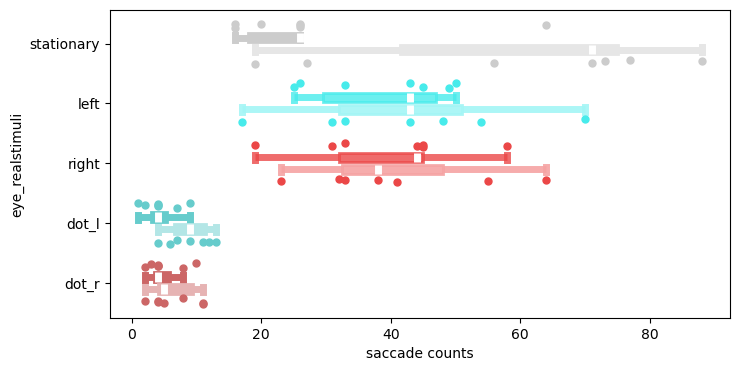

In [8]:
#count frequency
freq_df = (
    all_dfs
    .groupby(['fish_id', 'eye_realstimuli', 'Genotype'])
    .size()
    .reset_index(name='saccade_freq')
)

#plot
def plot_fish_saccade(all_df, stimorder, params, genotype):

    fig, ax = plt.subplots(1, 1, figsize = (8, 4))
    bars = sns.boxplot(freq_df, y = 'eye_realstimuli', x = params,  hue = 'Genotype', dodge = True, ax = ax, order= stimorder, hue_order = genotype, orient = 'h', linewidth=5, linecolor='white', zorder =0, width = 0.4, gap = 0.2, legend = False)

    #asign colors to the bar: less important
    count = all_df.groupby(['eye_realstimuli', 'Genotype']).count()
    count = list(count.reindex(stimorder, level='eye_realstimuli').iloc[:, 0])
    v = 0
    for i in range(len(count)):
        if count[i] > 0:  #box exist
            stim = stimorder[v % len(stimorder)]
            color = list(utils.stim_colors[stim])
            color = np.array(color)
            if i // (len(stimorder) ) != 0:
                color = 0.5 + 0.5 * np.array(color)
            bar = bars.patches[v]
            bar.set_edgecolor(color)
            bar.set_facecolor(color)
            bar.set_linewidth(2)
            for k in range(v * 6, (v + 1) * 6):
                if k != 4 + v * 6:
                    ax.lines[k].set_color(color)
            v += 1

    #plot scatter plot
    group_coord = [(-0.35, -0.25), (0.25, 0.35)]#[(-0.3, -0.28), (-0.12, -0.1), (0.1, 0.12), (0.28, 0.3)]#
    for i in range(0, len(stimorder)):
        for group_i, group in enumerate(genotype):
            x = stimorder[i]
            datatoplot = all_df[all_df.Genotype == group]
            y = list(datatoplot[datatoplot['eye_realstimuli'] == stimorder[i]][params])
            color = utils.stim_colors[x]
            ax.scatter(y = np.add([i] * len(y), np.random.uniform(group_coord[group_i][0], group_coord[group_i][1], len(y))), x=y,
                            color = color, alpha =1, s = 100, zorder = 1, marker = '.')

    ax.set_xlabel('saccade counts')
fig = plot_fish_saccade(freq_df, stimorder, 'saccade_freq', genotypes.keys())
plt.savefig(r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\all_behavior\individual_counts_byfish.svg")
plt.show()
plt.close()

__TASK 2: DURING STATIONARY PERIOD, DO FRMD7KO FISH EXPERIENCE "involuntary changes in the direction of their eye movements (periodic alternating nystagmus)"__

In [ ]:
#clue: consider plot the eye traces from eye_df in both fish
#clue: if there's periodic change, the current saccade is more likely to be the same direction as the previous saccade...

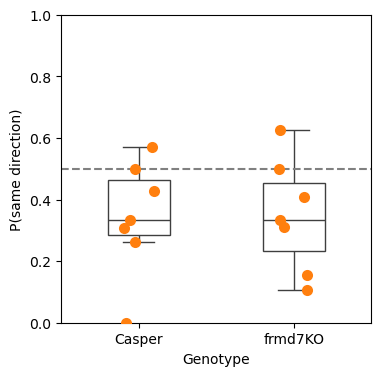

In [18]:

#create df
all_dfs['index'] = (
    all_dfs
    .groupby(['fish_id', 'eye_realstimuli'])
    .cumcount()
)

df_stat = all_dfs[
    #(all_dfs['eye_realstimuli'] == 'stationary') &
    (all_dfs['eye_stimuli'] == 'pause')].copy()

df_stat['direction'] = np.sign(df_stat['e_conj_change'])
df_stat = df_stat[df_stat['direction'] != 0]
df_stat = df_stat.sort_values(['fish_id', 'index'])
df_stat['prev_direction'] = df_stat.groupby('fish_id')['direction'].shift(1)
prob_df = (
    df_stat.groupby(['fish_id', 'Genotype'])[['direction', 'prev_direction']]
        .apply(lambda x: (x['direction'] == x['prev_direction']).mean())
        .reset_index(name='p_same_direction')
)

#plot
fig, ax = plt.subplots(1, 1, figsize = (4, 4))

sns.boxplot(
    data=prob_df,
    x='Genotype',
    y='p_same_direction',
    width = 0.4,
    showcaps = True,
    boxprops={'facecolor':'none'},
    showfliers=False, ax = ax)

sns.stripplot(
    data=prob_df,
    x='Genotype',
    y='p_same_direction',
    dodge=True,
    size=8, ax = ax
)

ax.axhline(0.5, linestyle='--', color='gray')
ax.set_ylim([0, 1])
ax.set_ylabel('P(same direction)')
plt.savefig(r"C:\Users\Zichen\Desktop\Taili\stationary.png")#(r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\all_behavior\stationary_freq.svg")

plt.show()
plt.close()

<>:104: SyntaxWarning: invalid escape sequence '\c'
<>:104: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Zichen\AppData\Local\Temp\ipykernel_28336\1656920707.py:104: SyntaxWarning: invalid escape sequence '\c'
  fig.savefig(f"Z:\cleo\Behaviors//frmd7//frmd7_hom_line1_okr_260409//all_behavior//saccade_acrosstime_{gene}.svg")


Casper
plotting behavior setup dot position
plotting behavior setup dot position


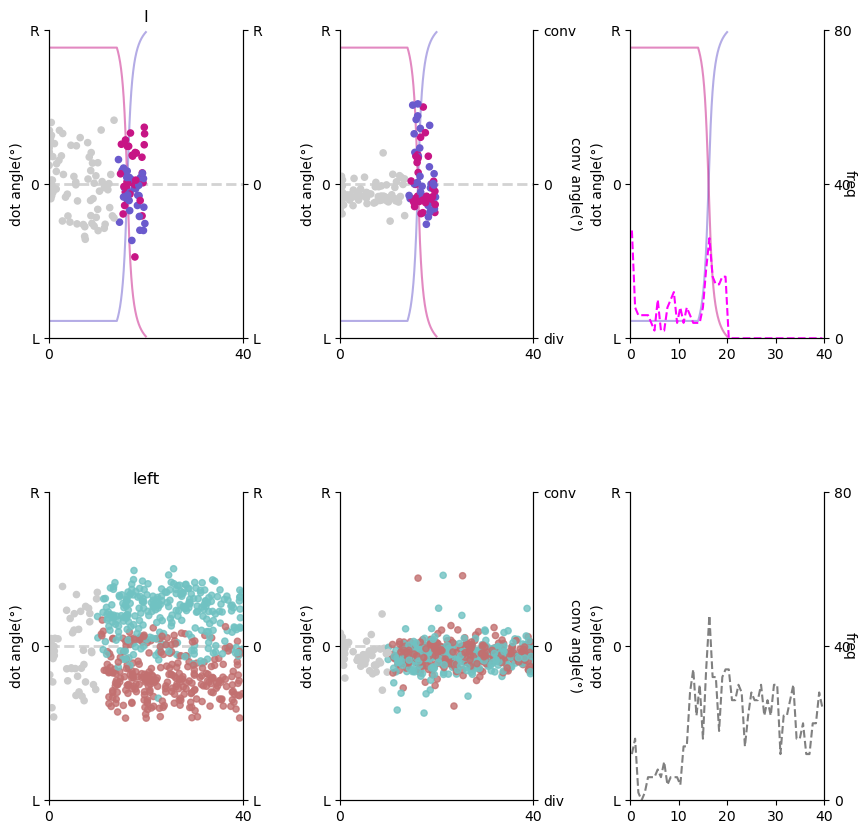

frmd7KO
plotting behavior setup dot position
plotting behavior setup dot position


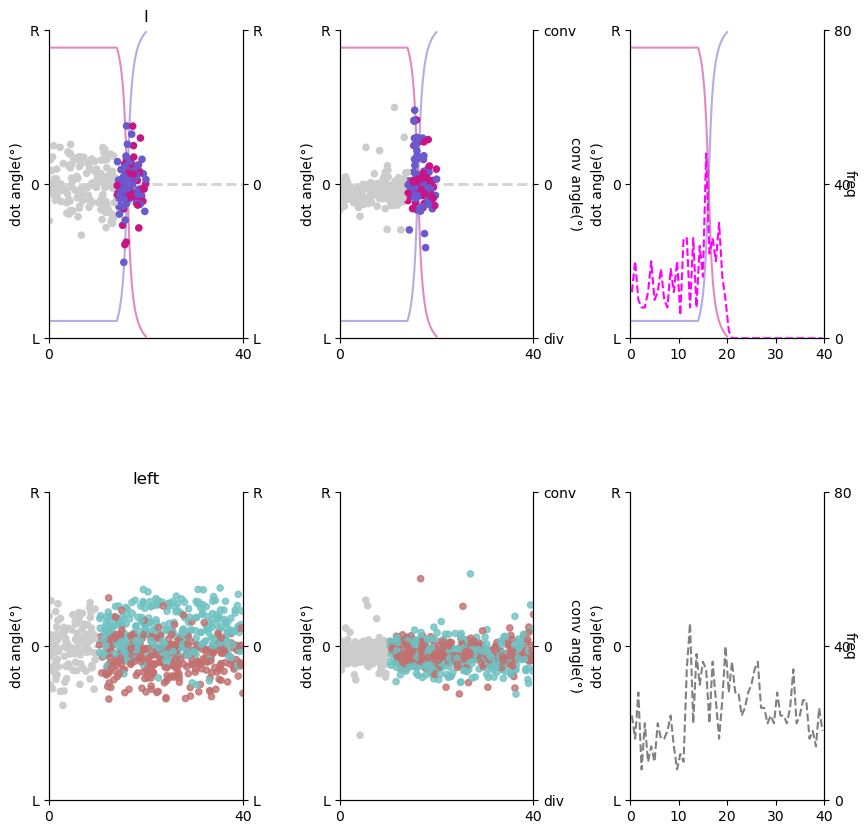

In [9]:
#plot changing eyes across time
stim_path = r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260409\okr_stim_260409.hdf"
stimulus_df = pd.read_hdf(stim_path, dtype=object).reset_index(drop=True)

stim_matrix = np.array([['dot_l', 'dot_r'],
                        ['left', 'right']])

# make stimulus file stationary friendly
for n, row in stimulus_df.iterrows():
    if type(row['stim_name']) == list and 'stationary' in row['stim_name'][1]:  # actual dot only
        stimulus_df.loc[n, 'stim_name'] = row['stim_name'][0]
        stimulus_df.loc[n, 'angle'] = row['angle'][0]
        stimulus_df.loc[n, 'stationary_time'] = row['stationary_time'][0]
        stimulus_df.loc[n, 'velocity'] = row['velocity'][0]
        stimulus_df.at[n, 'circle_center'] = [row['circle_center'][0]]
    if type(row['stim_name']) == list and 'stationary' in row['stim_name'][0]:  # actual grating only
        stimulus_df.loc[n, 'stim_name'] = row['stim_name'][1]
        stimulus_df.loc[n, 'angle'] = row['angle'][1]
        stimulus_df.loc[n, 'stationary_time'] = row['stationary_time'][1]
        stimulus_df.loc[n, 'velocity'] = row['velocity'][1]
        stimulus_df.at[n, 'circle_center'] = [row['circle_center'][1]]
stimulus_df.stim_name = [str(i) for i in stimulus_df.stim_name]

def plot_individual_saccade_overtime(all_df, stim_matrix, stims):
    fig, ax = plt.subplots(len(stim_matrix), 3, figsize = (10, 10), gridspec_kw = {'wspace': 0.5, 'hspace': 0.5})
    for n, row in enumerate(stim_matrix):
        for stim in row:
            if stim =='skip' or stim == 'pause' or '[' in stim:
                continue
            if 'dot_l' in stim:
                stimc = 'slateblue'
            elif 'dot_r' in stim:
                stimc = 'mediumvioletred'
            elif 'left' in stim:
                stimc = 'blue'
            elif 'right' in stim:
                stimc = 'red'
            # elif 'pause' in stim:
            #     stimc = 'grey'
            stim_df = stims[stims['stim_name'] == stim].iloc[0]
            _, stim_loc_timescale, stim_loc_scale, center_time= utils.get_dot_pos(stim_df, canvas_size=1024)
            #because it's behavior rig, stim_loc_scale got changed
            #stim_loc_scale = np.subtract(0, stim_loc_scale)
            [ax[n, col].plot(stim_loc_timescale, stim_loc_scale, c = stimc, alpha = 0.5, zorder = 0) for col in range(3)]
        row_saccade_df = all_df.loc[all_df['eye_stimuli'].isin(row)]
        stim_c = ['grey' if 'pause' in s else 'slateblue' if 'dot_l' in s else 'mediumvioletred' if 'dot_r' in s else utils.stim_colors[s] for s in row_saccade_df.eye_realstimuli]#['slateblue' if 'dot_l' in s else 'mediumvioletred' if 'dot_r' in s else 'grey' for s in row_saccade_df.eye_realstimuli]
        ax_conj = ax[n,0].twinx()
        ax_conj.scatter(row_saccade_df.eye_fromstart_s, row_saccade_df.e_conj_change, color = stim_c, s = 20, zorder = 2)
        ax_conv = ax[n,1].twinx()
        ax_conv.scatter(row_saccade_df.eye_fromstart_s, row_saccade_df.e_conv_change, color = stim_c, s = 20, zorder = 2)
        ax[n, 0].set_title(f"{row[0].split('_')[-1]}")
        ax[n, 0].set_ylabel('dot angle(°)')
        ax_conj.yaxis.set_label_position("right")
        ax[n, 1].set_ylabel('dot angle(°)')
        ax_conv.yaxis.set_label_position("right")
        ax_conv.set_ylabel('conv angle(°)', rotation = 270)
        #[ax[n, col].axvline(center_time, linewidth = 2, color = 'lightgrey', linestyle = '--', zorder = -1) for col in range(2)]
        [ax[n, col].axhline(0, linewidth = 2, color = 'lightgrey', linestyle = '--', zorder = -1)  for col in range(2)]
        [ax[n, col].set_xlim([0, 40]) for col in range(2)]
        [ax[n, col].set_xticks([0, 40]) for col in range(2)]
        [ax[n, col].set_ylim([-80, 80]) for col in range(2)]
        [ax[n, col].set_yticks([-80,0, 80]) for col in range(2)]
        [ax[n, col].set_yticklabels(['L', 0, 'R']) for col in range(2)]
        ax_conj.set_ylim([-80, 80])
        ax_conj.set_yticks([-80,0, 80])
        ax_conj.set_yticklabels(['L', 0, 'R'])
        ax_conv.set_ylim([-60, 60])
        ax_conv.set_yticks([-60,0, 60])
        ax_conv.set_yticklabels(['div', 0, 'conv'])
        [ax[n, col].spines[['top']].set_visible(False) for col in range(2)]
        ax_conv.spines[['top']].set_visible(False)
        ax_conj.spines[['top']].set_visible(False)

        #plot frequency over time
        ax_freq = ax[n,2].twinx()
        dot_stims = [s for s in row if 'dot' in s]
        nondot_stims = [s for s in row if 'dot' not in s]
        row_saccade_dot_df = row_saccade_df[row_saccade_df['eye_stimuli'].isin(dot_stims)]
        row_saccade_nondot_df = row_saccade_df[row_saccade_df['eye_stimuli'].isin(nondot_stims)]
        if len(row_saccade_dot_df) > 0:
            freq, bin_loc = np.histogram(row_saccade_dot_df.eye_fromstart_s, bins = 60, range = [0, 40])
            bin_center = (bin_loc[:-1] + bin_loc[1:]) / 2
            ax_freq.plot(bin_center, np.multiply(freq, 2), color = 'magenta', linestyle = '--', zorder = 1)
        if len(row_saccade_nondot_df) > 0:
            freq, bin_loc = np.histogram(row_saccade_nondot_df.eye_fromstart_s, bins = 60, range = [0, 40])
            bin_center = (bin_loc[:-1] + bin_loc[1:]) / 2
            ax_freq.plot(bin_center, np.multiply(freq, 2), color = 'grey', linestyle = '--', zorder = 1)
        ax_freq.spines[['top']].set_visible(False)
        ax[n,2].spines[['top']].set_visible(False)
        ax[n, 2].set_xlim([0, 40])
        ax_freq.set_xlim([0, 40])
        ax[n, 2].set_ylim([-80, 80])
        ax[n, 2].set_yticks([-80,0, 80])
        ax[n, 2].set_yticklabels(['L', 0, 'R'])
        ax_freq.set_ylim([0, 80])
        ax_freq.set_yticks([0, 40, 80])
        ax[n, 2].set_ylabel('dot angle(°)')
        ax_freq.set_ylabel('freq', rotation = -90)
    return fig

for gene in genotypes.keys():
    print(gene)
    fig = plot_individual_saccade_overtime(all_dfs[all_dfs.Genotype == gene], stim_matrix, stimulus_df)
    fig.savefig(f"Z:\cleo\Behaviors//frmd7//frmd7_hom_line1_okr_260409//all_behavior//saccade_acrosstime_{gene}.svg")
    plt.show()
    plt.close()

In [35]:
all_dfs

,cont_tuples_eyeindex,cont_tuples_realtime_s,e0_change,e1_change,eye_stimuli,eye_realstimuli,eye_fromstart_s,e_conv_change,e_conj_change,fish_id,Genotype,index
0,"(np.int64(87), np.int64(139))","(np.float64(-2.8045), np.float64(-2.226046))",-1.264237,-1.626258,NaN,NaN,NaN,-0.362021,-2.890495,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,Casper,NaN
1,"(np.int64(1522), np.int64(1630))","(np.float64(13.130886), np.float64(14.330677))",10.102415,-6.135414,right,right,13.130886,-16.237828,3.967001,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,Casper,0.0
2,"(np.int64(1727), np.int64(1782))","(np.float64(15.406799), np.float64(16.018165))",-1.254555,-1.563991,right,right,15.406799,-0.309436,-2.818546,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,Casper,1.0
3,"(np.int64(1835), np.int64(1915))","(np.float64(16.606591), np.float64(17.495214))",8.844805,-1.459430,right,right,16.606591,-10.304235,7.385374,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,Casper,2.0
4,"(np.int64(2416), np.int64(2493))","(np.float64(23.058338), np.float64(23.913052))",-2.095381,-8.986277,right,right,23.058338,-6.890896,-11.081659,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,Casper,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1917,"(np.int64(131689), np.int64(131768))","(np.float64(1459.780798), np.float64(1460.6554...",5.685289,7.620841,pause,stationary,258.498729,1.935552,13.306130,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,frmd7KO,83.0
1918,"(np.int64(132414), np.int64(132497))","(np.float64(1467.829275), np.float64(1468.7518...",-5.425105,-11.530452,pause,stationary,266.547206,-6.105347,-16.955557,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,frmd7KO,84.0
1919,"(np.int64(132743), np.int64(132816))","(np.float64(1471.484503), np.float64(1472.2933...",1.945051,5.908459,pause,stationary,270.202434,3.963408,7.853510,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,frmd7KO,85.0
1920,"(np.int64(133289), np.int64(133373))","(np.float64(1477.546289), np.float64(1478.4787...",10.449160,4.143174,pause,stationary,276.264220,-6.305986,14.592334,Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_26...,frmd7KO,86.0
